# Восстановление пайплайна: выбор детектора этикетки, заливки и предобработки веток

**Статус: архив экспериментов 21–22.09.2026.** Здесь собраны эксперименты, по которым выбраны настройки, действующие в пайплайне до сих пор: чекпойнт RT-DETR для этикетки (BF16), цвет заливки, предобработка для веток OCR и XFeat. Сквозные метрики и решающий слой того времени (`index_platform`, `decider_platform_paddle`) устарели и из ноутбука убраны: актуальное обучение решающего слоя — в ноутбуке 06, разбор ошибок на тесте — в ноутбуке 08.

**Правила экспериментов:**
1. **Выбор только по train:** настройки выбираются по валидационным винам из train. Тест не используется ни для обучения, ни для выбора эпохи или порога.
2. **Только сохранённые результаты:** каждая таблица читается из реального сохранённого файла. Если файла нет, это незавершённый шаг, а не нулевая метрика.
3. **Ветки независимы:** цветной кроп остаётся входом SigLIP 2, а grayscale и CLAHE проверяются как отдельные варианты для веток OCR и XFeat. Заливка добавляется **вокруг прямоугольного кропа**, когда он дополняется до квадрата; она не закрашивает бутылку и не удаляет фон внутри её рамки.

In [1]:
from pathlib import Path
import json, os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
ROOT = Path.cwd()
if not (ROOT / 'pyproject.toml').exists(): ROOT = ROOT.parent
os.chdir(ROOT)
sys.path.insert(0, str(ROOT))
from wine_scanner.embed import load_image
from wine_scanner.embed.branches import branch_image
from scripts.audit_rtdetr_crops import summarize
def read(path):
    p = ROOT / path
    return json.loads(p.read_text(encoding='utf-8')) if p.exists() else None
def records(path):
    p = ROOT / path
    return [json.loads(s) for s in p.read_text(encoding='utf-8').splitlines()] if p.exists() else []
display(pd.Series(read('models/siglip2/provenance.json') or {'status':'missing'}))


G:\Projects\python\rshb_my_wine_app\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


repository                              google/siglip2-so400m-patch16-384
revision                         dd658faac399427308559e2c3ac1e99cbe43845d
model_sha256            422750e06216f053d85d4176fb6a9d4c5e71ded2d1b7c7...
verified_against_hub                                                 True
dtype: object

## 1. Переобучение этикетки и контроль численной устойчивости

Разметка перенесена вычитанием начала кропа и пересечением рамки с его границами.
Потерянную за границей часть изображения восстановить преобразованием координат нельзя.
Деление собственных кадров идёт по винам; близкие фотографии одной бутылки не должны
попадать одновременно в обучение и validation. Тест не используется для выбора эпохи.

Первый FP16-прогон дал нулевую долю детекций выше 0,3. В отдельной диагностике FP16 имел
нечисловые градиенты и пропускал шаги; BF16 на проверенных батчах имел конечные градиенты.
Это наблюдение само по себе не доказывает причину провала. Повторный прогон контролирует
градиенты и сохраняет полную историю, включая неулучшившиеся эпохи.


rtdetr_label_recrop selected epoch: 1


,epoch,detection_rate,mean_iou,iou@0.75
0,1,0.0,0.0,0.0


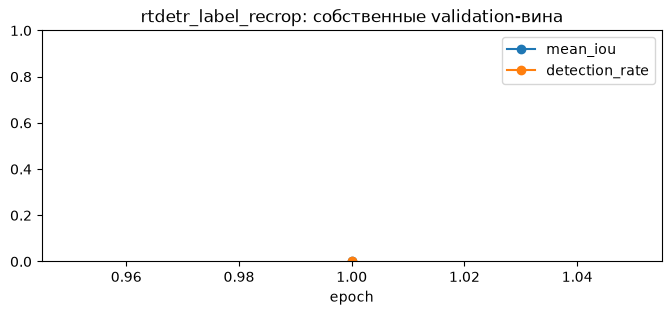

rtdetr_label_recrop_bf16 selected epoch: 4


,epoch,detection_rate,mean_iou,iou@0.75,external_valid,loss,skipped_steps,gradient_scale
0,1,1.0,0.940068,1.0,"{'detection_rate': 0.9983498349834984, 'mean_i...",12.544494,0,1.0
1,2,1.0,0.939770,1.0,"{'detection_rate': 1.0, 'mean_iou': 0.94066834...",7.569834,0,1.0
2,3,1.0,0.936759,1.0,"{'detection_rate': 1.0, 'mean_iou': 0.93027769...",7.010296,0,1.0
3,4,1.0,0.942768,1.0,"{'detection_rate': 1.0, 'mean_iou': 0.94419395...",6.544272,0,1.0
4,5,1.0,0.936396,1.0,"{'detection_rate': 1.0, 'mean_iou': 0.94060523...",6.174730,0,1.0
5,6,1.0,0.942002,1.0,"{'detection_rate': 1.0, 'mean_iou': 0.95035871...",5.886692,0,1.0
6,7,1.0,0.940539,1.0,"{'detection_rate': 1.0, 'mean_iou': 0.94416625...",5.596488,0,1.0


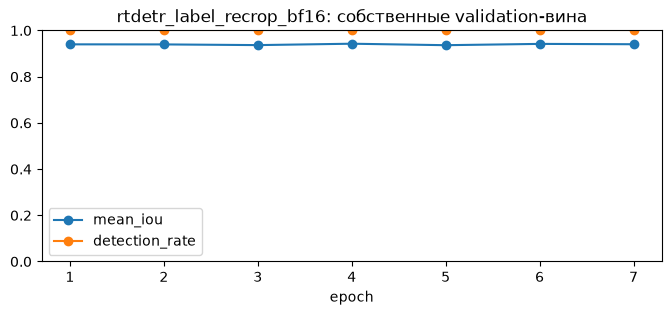

In [2]:
for folder in ('rtdetr_label_recrop', 'rtdetr_label_recrop_bf16'):
    meta = read(f'models/{folder}/training.json')
    hist = read(f'models/{folder}/history.json') or (meta or {}).get('history', [])
    print(folder, 'selected epoch:', (meta or {}).get('best_epoch', 'not ready'))
    if hist:
        frame = pd.DataFrame(hist)
        display(frame)
        frame.plot(x='epoch', y=['mean_iou','detection_rate'], marker='o', ylim=(0,1),
                   title=folder + ': собственные validation-вина', figsize=(8,3))
        plt.show()
    else: print('История ещё не готова')


### Выводы по переобучению детектора этикетки

1. **FP16 не подошёл:** первый прогон в FP16 не дал ни одной детекции выше порога 0,3 — обучение было численно нестабильным.
2. **BF16 стабилен:** на собственных валидационных винах доля найденных этикеток равна 1,0 во всех эпохах, средний IoU около 0,94.
3. **Выбор чекпойнта:** эпоха выбирается по валидации (эпоха 4), тест в этом не участвует. Эта модель (`rtdetr_label_recrop_bf16`) используется в пайплайне и сейчас.

## 2. Качество кропов до и после переобучения

IoU считается в координатах исходного кадра, нулевая детекция даёт IoU=0.
Fallback сохраняет всю бутылку, поэтому отсутствие детекции не означает потерю пикселей.
Здесь измеряется выбранная этикетка, **это не COCO mAP**. Несколько этикеток на полке и
единая рамка вокруг раздельных бумажных элементов требуют отдельной политики разметки.


,group,images,errors,bottle_fallbacks,label_fallbacks,annotated_images,gt_labels,selected_mean_iou_frame,selected_iou_ge_50,selected_iou_ge_75,gt_retained_ge_99,gt_lost,gt_clipped,label_crop_any_gt_retained_ge_99,model
0,test/frames_annotated,332.0,0.0,42.0,4.0,145.0,145.0,0.937644,0.986207,0.972414,1.000000,0.0,0.0,NaN,baseline
1,train/frames_annotated,165.0,0.0,14.0,1.0,165.0,183.0,0.896290,0.969697,0.957576,0.956284,8.0,0.0,NaN,baseline
7,test/labels_legacy_crops,164.0,0.0,9.0,1.0,132.0,132.0,0.938308,0.992424,0.992424,1.000000,0.0,0.0,NaN,baseline
10,train/labels_legacy_crops,169.0,0.0,11.0,1.0,153.0,153.0,0.951313,1.000000,0.993464,1.000000,0.0,0.0,NaN,baseline
12,roboflow/test,309.0,0.0,14.0,0.0,309.0,319.0,0.918762,0.980583,0.944984,0.981191,1.0,5.0,NaN,baseline
13,roboflow/train,5175.0,0.0,825.0,111.0,5175.0,12476.0,0.863546,0.947826,0.895266,0.902292,665.0,554.0,NaN,baseline
14,roboflow/valid,607.0,0.0,33.0,2.0,607.0,612.0,0.921505,0.980231,0.952224,0.986928,4.0,4.0,NaN,baseline
0,test/frames_annotated,332.0,0.0,42.0,0.0,145.0,145.0,0.942917,0.993103,0.972414,1.000000,0.0,0.0,0.937931,retrained
1,train/frames_annotated,165.0,0.0,14.0,0.0,165.0,183.0,0.954150,1.000000,1.000000,0.956284,8.0,0.0,1.000000,retrained
2,test/labels_legacy_crops,164.0,0.0,9.0,0.0,132.0,132.0,0.938635,1.000000,1.000000,1.000000,0.0,0.0,0.984848,retrained


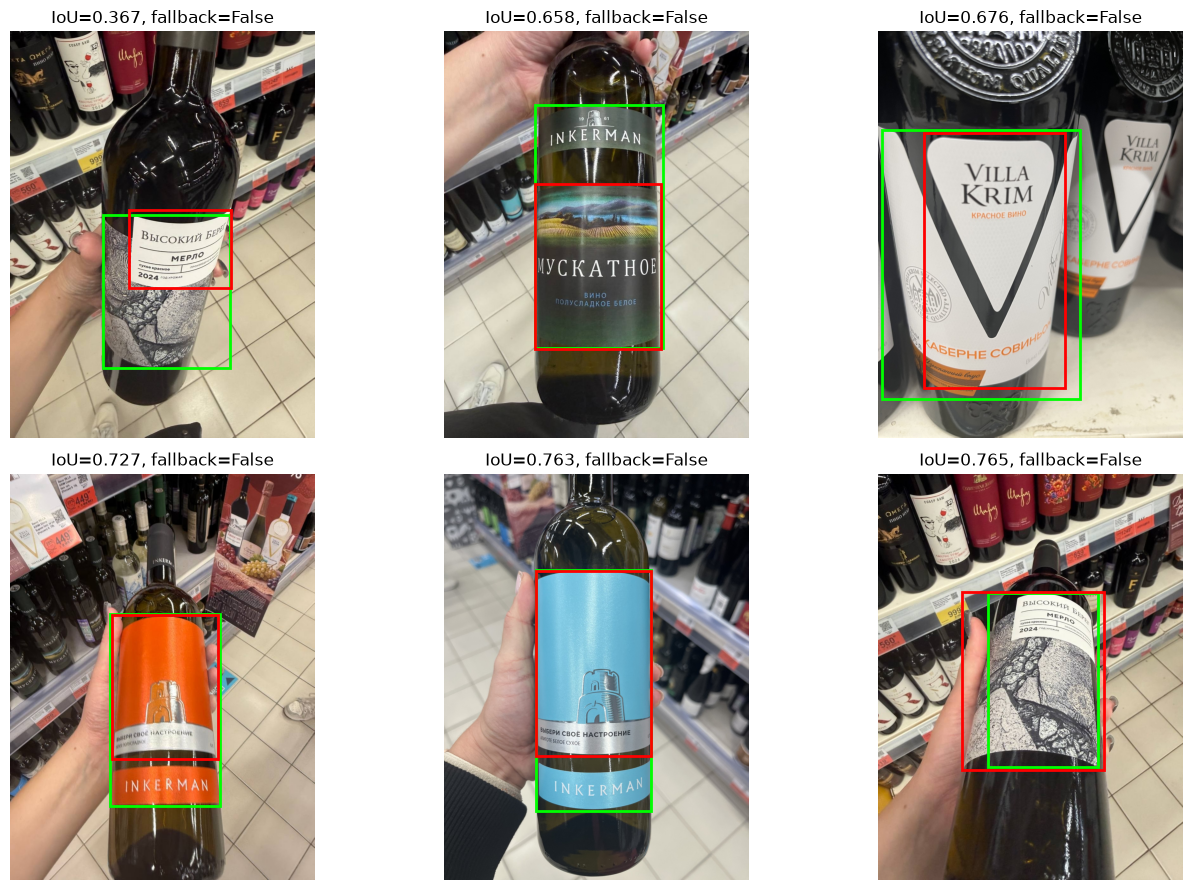

In [3]:
baseline = records('data/derived/rtdetr_audit/records.jsonl')
updated = records('data/derived/rtdetr_retrained_audit/records.jsonl')
tables = []
for name, rows in [('baseline',baseline), ('retrained',updated)]:
    if rows:
        table = pd.DataFrame(summarize(rows)).T
        table['model'] = name
        tables.append(table.reset_index(names='group'))
if tables:
    comparison = pd.concat(tables)
    display(comparison[comparison.annotated_images > 0])
if updated:
    chosen = sorted([r for r in updated if r['group']=='test/frames_annotated' and r['gt_labels']],
                    key=lambda r:r['selected_label_iou_frame'])[:6]
    from matplotlib.patches import Rectangle
    fig, axes = plt.subplots(2,3,figsize=(14,9))
    for ax,r in zip(axes.flat,chosen):
        ax.imshow(load_image(r['source']))
        for box in r['gt_labels']:
            x,y,x2,y2=box
            ax.add_patch(Rectangle((x,y),x2-x,y2-y,fill=False,color='lime',lw=2))
        if r['selected_label_frame']:
            x,y,x2,y2=r['selected_label_frame']
            ax.add_patch(Rectangle((x,y),x2-x,y2-y,fill=False,color='red',lw=2))
        ax.set_title(f"IoU={r['selected_label_iou_frame']:.3f}, fallback={r['label_fallback']}")
        ax.axis('off')
    plt.tight_layout(); plt.show()
else: print('Обновлённый аудит ещё не выполнен')


### Выводы по качеству кропов

Кропы нужно оценивать до поиска: этикетку, потерянную на этапе кропа, эмбеддинг-модель уже не восстановит. Фоллбэк (возврат всей бутылки вместо этикетки) сохраняет данные, но сам по себе не считается успешной детекцией. Подробный разбор худших кропов — в ноутбуке 02.

## 3. Цвет полей вокруг кропа

Один и тот же цвет применяется к каталогу и запросам. Мера выбора — средний Recall@1
по винам, при равенстве Recall@5; при полном равенстве остаётся прежняя настройка.
На малом числе вин разница в один кадр — слабое доказательство. Это ablation визуального
поиска, а не итоговая точность всего сервиса.


In [4]:
for filename in ('padding_validation.json','padding_retrained_validation.json'):
    report=read('data/derived/'+filename)
    if report:
        print(filename, 'selection:', report['selection'], 'wines:',report['validation_wines'])
        display(pd.DataFrame(report['results']).T)


padding_validation.json selection: white wines: ['Baron_Philippe_de_Rothschild_MoutonCadet_2022_bordeaux_red', 'Baron_Philippe_de_Rothschild_MoutonCadet_2023_bordeaux_white', 'Chateau_Tamagne_красное_2025', 'Ff_Clou_du_pin_chateau_2021_bordeaux_superieur_premium', 'Ladofoods_Vang_Dalat_export_white_wine']


,fill,queries,catalog,r1,r5,wine_macro_r1,wine_macro_r5
current,"[124, 116, 104]",30,20,0.766667,0.933333,0.76,0.933333
neutral,"[128, 128, 128]",30,20,0.766667,0.933333,0.76,0.933333
white,"[255, 255, 255]",30,20,0.8,0.933333,0.8,0.933333
black,"[0, 0, 0]",30,20,0.766667,0.933333,0.771429,0.933333


padding_retrained_validation.json selection: white wines: ['Baron_Philippe_de_Rothschild_MoutonCadet_2022_bordeaux_red', 'Ff_Clou_du_pin_chateau_2021_bordeaux_superieur_premium', 'Ladofoods_Excellence_sauvignon_blanc_white_wine', 'Ladofoods_Vang_Dalat_classic_special_red_wine']


,fill,queries,catalog,r1,r5,wine_macro_r1,wine_macro_r5
current,"[124, 116, 104]",24,20,0.833333,1.0,0.833333,1.0
neutral,"[128, 128, 128]",24,20,0.833333,1.0,0.833333,1.0
white,"[255, 255, 255]",24,20,0.875,1.0,0.875,1.0
black,"[0, 0, 0]",24,20,0.875,1.0,0.875,1.0


### Выводы по цвету заливки

1. **Одинаково для запроса и каталога:** заливка — часть пространства признаков, поэтому она должна совпадать у запросов и у карточек каталога.
2. **Белый лучше или не хуже остальных:** в первом прогоне белый дал Recall@1 0,80 против 0,77 у прежнего цвета, после переобучения детектора — 0,875 против 0,833 (наравне с чёрным). Но это разница в один-два кадра на 4–5 винах, то есть слабое доказательство.
3. **Что сейчас:** с 23.09 используется предобработка `label-square-v3` — квадрат вырезается из исходного кадра, и заливка берёт цвет фона снимка (подробнее — ноутбук 02, раздел 7).

## 4. RGB, grayscale и CLAHE — отдельные эксперименты для OCR и XFeat

Для выбора OCR основной критерий — macro R@5, затем R@1: в CatBoost идут пять текстовых
кандидатов. Для XFeat основной критерий — macro R@1, затем R@5 по числу
RANSAC-инлаеров. Равные нулевые оценки считаются неудачей, а не удачным первым местом.
Название из БД не является полной посимвольной транскрипцией фото: `cer_proxy` — только
диагностический показатель, его нельзя выдавать за настоящий OCR CER.

CLAHE усиливает локальный контраст, но может усилить блики, фактуру бумаги и шум.
Поэтому увеличение числа совпадений без улучшения ранга правильного вина — не победа.


baseline 30 queries; 5 wines


,text_macro_r1,text_macro_r5,geometry_macro_r1,geometry_macro_r5,mean_true_inliers,seconds
rgb,0.482857,0.764762,0.860000,0.926667,614.833333,427.814517
gray,0.454286,0.764762,0.893333,0.893333,612.200000,418.109721
clahe2,0.416190,0.798095,0.860000,0.860000,614.700000,372.375389
clahe4,0.416190,0.764762,0.860000,0.893333,609.266667,288.315252


Выбор OCR: preliminary XFeat: preliminary


,true_inliers,true_inlier_ratio,true_reprojection
mode,,,
clahe2,390.0,0.627362,1.912276
clahe4,375.5,0.607284,1.949918
gray,376.5,0.628207,1.858278
rgb,383.0,0.629466,1.875680


queries  geometry_r1  text_r5  median_inlier_ratio  \
mode   condition                                                       
clahe2 angle            5          1.0      1.0             0.479268   
       blur             5          0.6      0.0             0.385827   
       catalog          5          1.0      1.0             1.000000   
       far              5          0.6      0.8             0.644315   
       glare            6          1.0      1.0             0.569450   
       partial          4          1.0      1.0             0.802848   
clahe4 angle            5          1.0      1.0             0.438750   
       blur             5          0.6      0.0             0.500000   
       catalog          5          1.0      1.0             1.000000   
       far              5          0.6      0.6             0.604520   
       glare            6          1.0      1.0             0.556063   
       partial          4          1.0      1.0             0.792226   
gray   angle            5          1.0      1.0             0.447761   
       blur             5          0.8      0.0             0.416667   
       catalog          5          1.0      1.0             1.000000   
       far              5          0.6      0.6             0.614776   
       glare            6          1.0      1.0             0.615357   
       partial          4          1.0      1.0             0.817403   
rgb    angle            5          1.0      1.0             0.413366   
       blur             5          0.6      0.0             0.500000   
       catalog          5          1.0      1.0             1.000000   
       far              5          0.6      0.6             0.578811   
       glare            6          1.0      1.0             0.624576   
       partial          4          1.0      1.0             0.817094   

                  median_reprojection  
mode   condition                       
clahe2 angle                 2.093292  
       blur                  2.255045  
       catalog               0.000000  
       far                   1.580660  
       glare                 1.912276  
       partial               1.879336  
clahe4 angle                 2.062136  
       blur                  2.237728  
       catalog               0.000000  
       far                   1.657418  
       glare                 2.016136  
       partial               1.878388  
gray   angle                 2.032723  
       blur                  2.223927  
       catalog               0.000000  
       far                   1.448161  
       glare                 2.018793  
       partial               1.854301  
rgb    angle                 2.076632  
       blur                  1.893820  
       catalog               0.000000  
       far                   1.628617  
       glare                 2.076674  
       partial               1.860260

...

,text_macro_r1,text_macro_r5,geometry_macro_r1,geometry_macro_r5,mean_true_inliers,seconds
rgb,0.541667,0.791667,0.916667,0.958333,599.000000,18.262147
gray,0.500000,0.791667,0.875000,0.958333,598.875000,14.647652
clahe2,0.458333,0.791667,0.916667,1.000000,586.625000,15.195982
clahe4,0.375000,0.708333,0.916667,1.000000,578.958333,14.991553


Выбор OCR: rgb XFeat: clahe2


,delta_vs_rgb,ci95
rgb:text_rank:r5,0.0,"[0.0, 0.0]"
gray:text_rank:r5,0.0,"[0.0, 0.0]"
clahe2:text_rank:r5,0.0,"[0.0, 0.0]"
clahe4:text_rank:r5,-0.083333,"[-0.16666666666666674, 0.0]"
rgb:geometry_rank:r1,0.0,"[0.0, 0.0]"
gray:geometry_rank:r1,-0.041667,"[-0.12499999999999997, 0.0]"
clahe2:geometry_rank:r1,0.0,"[-0.12499999999999997, 0.12500000000000006]"
clahe4:geometry_rank:r1,0.0,"[0.0, 0.0]"


,true_inliers,true_inlier_ratio,true_reprojection
mode,,,
clahe2,328.5,0.652004,2.026800
clahe4,336.5,0.596122,2.098055
gray,374.5,0.643389,2.010710
rgb,382.0,0.632298,1.956645


queries  geometry_r1  text_r5  median_inlier_ratio  \
mode   condition                                                       
clahe2 angle            4         1.00     1.00             0.486017   
       blur             4         0.75     0.00             0.411416   
       catalog          4         1.00     1.00             1.000000   
       far              4         1.00     0.75             0.671929   
       glare            4         0.75     1.00             0.490992   
       partial          4         1.00     1.00             0.738588   
clahe4 angle            4         1.00     1.00             0.464965   
       blur             4         0.75     0.00             0.387343   
       catalog          4         1.00     1.00             1.000000   
       far              4         1.00     0.25             0.621809   
       glare            4         0.75     1.00             0.424262   
       partial          4         1.00     1.00             0.705698   
gray   angle            4         1.00     1.00             0.509519   
       blur             4         0.75     0.00             0.434969   
       catalog          4         1.00     1.00             1.000000   
       far              4         0.75     0.75             0.695020   
       glare            4         0.75     1.00             0.517570   
       partial          4         1.00     1.00             0.802723   
rgb    angle            4         1.00     1.00             0.526679   
       blur             4         0.75     0.00             0.476191   
       catalog          4         1.00     1.00             1.000000   
       far              4         1.00     0.75             0.683393   
       glare            4         0.75     1.00             0.486124   
       partial          4         1.00     1.00             0.807828   

                  median_reprojection  
mode   condition                       
clahe2 angle             2.042041e+00  
       blur              2.057622e+00  
       catalog           0.000000e+00  
       far               2.165212e+00  
       glare             2.185361e+00  
       partial           2.026800e+00  
clahe4 angle             2.195464e+00  
       blur              2.182841e+00  
       catalog           1.672040e-20  
       far               2.138478e+00  
       glare             2.195676e+00  
       partial           2.074005e+00  
gray   angle             2.057301e+00  
       blur              2.163592e+00  
       catalog           0.000000e+00  
       far               1.890666e+00  
       glare             2.081822e+00  
       partial           1.900889e+00  
rgb    angle             2.241759e+00  
       blur              2.018567e+00  
       catalog           1.759994e-19  
       far               1.865031e+00  
       glare             2.022242e+00  
       partial           1.988860e+00

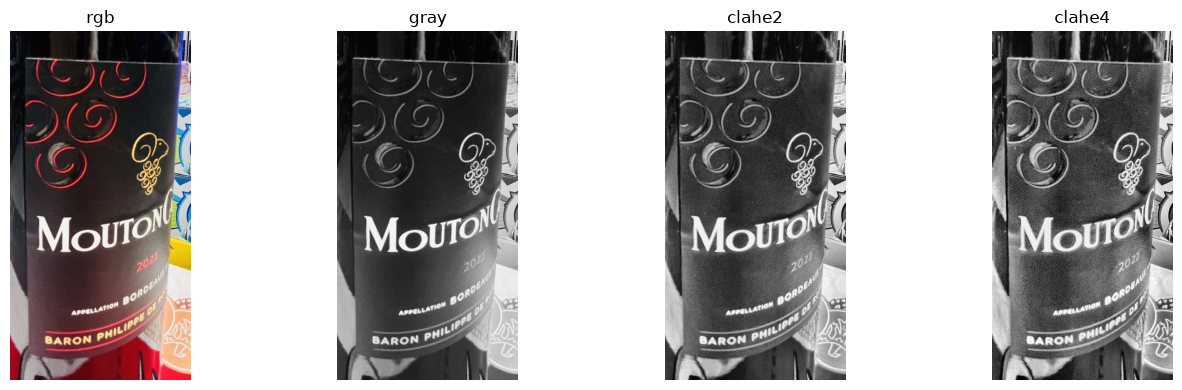

In [5]:
branch_reports={}
for tag in ('baseline','retrained'):
    report=read(f'data/derived/branches_{tag}.json')
    if report:
        branch_reports[tag]=report
        print(tag, report['queries'], 'queries;',len(report['validation_wines']),'wines')
        display(pd.DataFrame(report['summary']).T)
        print('Выбор OCR:',report.get('selected_ocr','preliminary'),
              'XFeat:',report.get('selected_local','preliminary'))
        if report.get('paired_wine_bootstrap'):
            display(pd.DataFrame(report['paired_wine_bootstrap']).T)
        table=pd.DataFrame(report['records'])
        display(table.groupby('mode')[['true_inliers','true_inlier_ratio','true_reprojection']].median())
        table['condition']=table['query'].map(lambda p:Path(p).stem.split('_')[0])
        table['geometry_top1']=table.geometry_rank <= 1
        table['text_top5']=table.text_rank <= 5
        display(table.groupby(['mode','condition']).agg(
            queries=('wine','size'), geometry_r1=('geometry_top1','mean'),
            text_r5=('text_top5','mean'), median_inlier_ratio=('true_inlier_ratio','median'),
            median_reprojection=('true_reprojection','median')))
rows=updated or baseline
examples=[r for r in rows if r.get('group')=='train/frames_annotated' and not r.get('error')]
if examples:
    image=load_image(examples[0]['label_crop'])
    fig,axes=plt.subplots(1,4,figsize=(14,4))
    for ax,mode in zip(axes,('rgb','gray','clahe2','clahe4')):
        ax.imshow(branch_image(image,mode));ax.set_title(mode);ax.axis('off')
    plt.tight_layout();plt.show()


### Выводы по предобработке веток

1. **OCR читает цветной кроп (RGB):** ни grayscale, ни CLAHE не улучшили попадание верного вина в пятёрку текстовой ветки.
2. **XFeat работает на CLAHE 2:** Recall@1 по геометрии такой же, как у RGB (0,92), а Recall@5 выше (1,00 против 0,96).
3. **Осторожность:** выборка маленькая (24 кадра, 4 вина), поэтому выбор проверялся парным bootstrap по винам. Оба выбора действуют до сих пор (`--local-preprocess clahe2` при сборке индекса).

## 5. Цилиндрическая этикетка и геометрические признаки

Гомография точно описывает перспективу плоскости. Вся поверхность цилиндра плоскостью
не является; одна гомография может подтвердить центральный участок и отвергнуть края.
Поэтому CatBoost получает не только число инлаеров, но и их долю, площадь покрытия
кропа и ошибку репроекции, нормированную на диагональ изображения.

Автоматическая развёртка требует оценки оси, радиуса и положения камеры. Ошибочная
развёртка сама деформирует буквы. Пока нет отдельного замера на размеченных ракурсах,
включать её постоянно нельзя. Следующий обоснованный эксперимент — отдельные группы
фронтальных и боковых кадров, затем проверка выигрыша развёртки на отложенных винах.

[OpenCV: область применимости гомографии](https://docs.opencv.org/4.x/d9/dab/tutorial_homography.html).


### Выводы по цилиндрической этикетке

Одна гомография не описывает цилиндрическую поверхность бутылки. Пока развёртка этикетки не доказала выигрыш на отложенных ракурсах, в пайплайне остаются измеримые признаки RANSAC: число и доля инлаеров, покрытие кропа и ошибка репроекции.

## Итог

1. **Детектор этикетки:** RT-DETR, обученный в BF16 и выбранный по валидации (`rtdetr_label_recrop_bf16`).
2. **Заливка:** одинаковая для запросов и каталога; сейчас — цвет фона кадра (`label-square-v3`).
3. **Предобработка веток:** SigLIP 2 получает цветной кроп, OCR — цветной кроп, XFeat — CLAHE 2.
4. **Что дальше не здесь:** признаки и обучение решающего слоя — ноутбук 06, итог на тесте и разбор ошибок — ноутбук 08.